In [287]:
import torch
import torch.nn as nn
import torchvision
import matplotlib as plt
import torchvision.transforms as Transforms
import torch.optim as optims
from torch.utils.data import DataLoader

In [288]:
#saare train aur test dataset load kiye..

#train_dataset = torchvision.datasets.MNIST(root='./data', train = True, transform = my_transform, download=True)

#test_dataset = torchvision.datasets.MNIST(root='./data', train = False, transform=Transforms.ToTensor(),download=True)

In [289]:
#train_dataloader  = DataLoader(dataset= train_dataset, batch_size = 64, shuffle = True)
#test_dataloader = DataLoader(dataset= test_dataset, batch_size= 64, shuffle= False)

In [290]:
#now peeche humne jo image load kiye the unhe Tensors me bhi convert krliya but covnert krne ke baad humenormalize bhi krna hota hai
#so now, hum neeche manually normalize krna cahhte hai.. so we defined a normalizer function.
#normalizer = Transforms.Normalize(mean=(0.5,),std=(0.5,))

In [291]:
#now executing the given below code gives error,
#kyuki jo humara normalizer function hai, it expects an image and train_dataset hai woh rather ek container hai
#jisme hum sare dataset ko store kiye hai, and we are not passing an image usme.. there for this si wrong

#normalized_tensor = normalizer(train_dataset)

#the right way:

#for images,labels in train_dataloader:

#    images = normalizer(images)

#the images have been normalized but the thing is ki, it was tiring part.. itna kaun likhega so there's a better way

In [292]:
my_transform = Transforms.Compose([
    Transforms.ToTensor(),
    Transforms.Normalize((0.5,),(0.5,)),
    Transforms.Lambda(lambda x: x.view(-1))#this converts the image tensor into a 1d vector. since we are using ANN
])

In [293]:
train_dataset = torchvision.datasets.MNIST(root= './data', train = True, transform= my_transform, download = True)
test_dataset = torchvision.datasets.MNIST(root='./data',train= False, transform=my_transform, download = True)

In [294]:
train_dataloader = DataLoader(dataset=train_dataset, batch_size = 64, shuffle= True)
test_dataloader = DataLoader(dataset = test_dataset,batch_size=64,shuffle=False)
#now the stuff we have inside the train_dataloader for each image is a flat 28*28 1d vector and is normalized between -1 and 1

before getting into the class function, i would like to tell that why are we doing it at the first place? like humlog directly bhi import krke kr skte the.. why to make the class inherit the nn.module?? 
its because ki jab hum inherit krate hai tb jo humara jo pura class hai usko hum as a neural network itself treat kr skte hai.. and after that we can use alot many functions like .parametres, .todevice() and many more like save and load..

now a question arises, ki why cant we import and do it??

what inheriting here does is that it secretly creates a small container in which it stores the weights everytime you call a new layer, whereas this is not possible if you jjust import, coz you will have to store teh weights manually




In [295]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.layer1 = nn.Linear(in_features=28*28,out_features=256)

        self.relu = nn.ReLU()

        self.layer2 = nn.Linear(in_features=256,out_features=10)

        self.relu = nn.ReLU()


    def forward(self,x):
        x = self.relu(self.layer1(x))

        x = self.layer2(x)

        return x    

In [296]:
class ANN_2l(nn.Module):
    def __init__(self):
        super(ANN_2l,self).__init__()

        self.layer1 = nn.Linear(in_features=28*28, out_features=256)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(in_features=256, out_features=128)
        self.relu = nn.ReLU()
        self.layer3 = nn.Linear(in_features=128,out_features=10)


    def forward(self,x):
        x= self.relu(self.layer1(x))
        x= self.relu(self.layer2(x))
        x=self.layer3(x)

        return x
        

In [297]:
model = ANN_2l()
criterion = nn.CrossEntropyLoss()
optimizer = optims.SGD(model.parameters(), lr=0.0780)


In [298]:
num_epochs = 25

In [299]:
for epoch in range(num_epochs):

    for i,(images,labels) in enumerate(train_dataloader):

        output = model(images)

        loss = criterion(output, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if (i+1) % 100 == 0:
            print(f'Epoch {epoch+1}, Step {i+1}, Loss: {loss.item()}')



Epoch 1, Step 100, Loss: 0.5908614993095398
Epoch 1, Step 200, Loss: 0.25751012563705444
Epoch 1, Step 300, Loss: 0.3422476649284363
Epoch 1, Step 400, Loss: 0.3794216215610504
Epoch 1, Step 500, Loss: 0.25940436124801636
Epoch 1, Step 600, Loss: 0.26558345556259155
Epoch 1, Step 700, Loss: 0.15253709256649017
Epoch 1, Step 800, Loss: 0.28922683000564575
Epoch 1, Step 900, Loss: 0.3782212436199188
Epoch 2, Step 100, Loss: 0.12864474952220917
Epoch 2, Step 200, Loss: 0.15805982053279877
Epoch 2, Step 300, Loss: 0.24416953325271606
Epoch 2, Step 400, Loss: 0.1173531636595726
Epoch 2, Step 500, Loss: 0.12469582259654999
Epoch 2, Step 600, Loss: 0.29405850172042847
Epoch 2, Step 700, Loss: 0.15711788833141327
Epoch 2, Step 800, Loss: 0.09757182002067566
Epoch 2, Step 900, Loss: 0.15520259737968445
Epoch 3, Step 100, Loss: 0.057453375309705734
Epoch 3, Step 200, Loss: 0.15296337008476257
Epoch 3, Step 300, Loss: 0.17284232378005981
Epoch 3, Step 400, Loss: 0.17462103068828583
Epoch 3, Step 

In [303]:
model.eval()

correct_count = 0
total_count = 0

with torch.no_grad():
    for images,labels in test_dataloader:

        output = model(images)

        _, prediction = torch.max(output.data,1)

        total_count += labels.size(0)
        correct_count += (prediction == labels).sum().item()



accuracy = 100 * correct_count / total_count
print(f'Accuracy on the 10,000 test images: {accuracy:.2f}%')

Accuracy on the 10,000 test images: 98.19%


In [301]:
print("  Actual | Predicted")
print("--------------------")
for i in range(10):
    actual = labels[i].item()
    guess = prediction[i].item()
    
    # Mark errors with an "X" for easy spotting
    status = "OK" if actual == guess else "WRONG!"
    print(f"     {actual}   |     {guess}     ({status})")

  Actual | Predicted
--------------------
     1   |     1     (OK)
     2   |     2     (OK)
     3   |     3     (OK)
     4   |     4     (OK)
     5   |     5     (OK)
     6   |     6     (OK)
     7   |     7     (OK)
     8   |     8     (OK)
     9   |     9     (OK)
     0   |     0     (OK)


IndexError: index 16 is out of bounds for dimension 0 with size 16

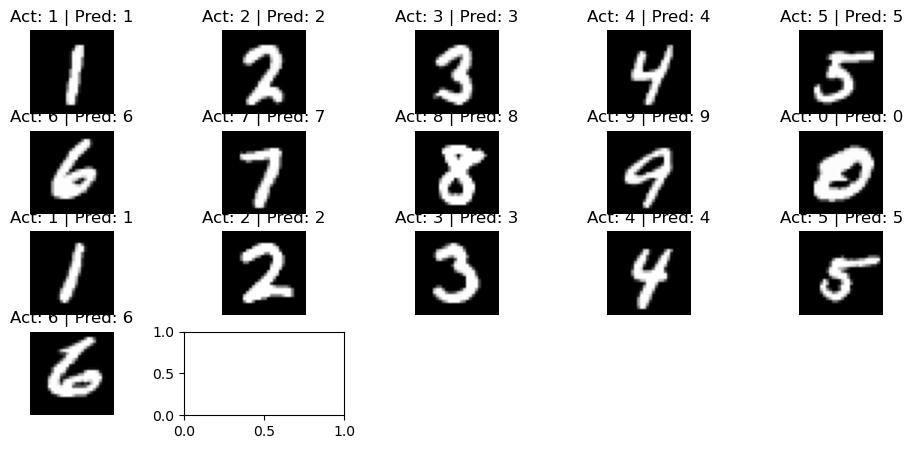

In [302]:
import matplotlib.pyplot as plt

# Plot the first 10 images
fig = plt.figure(figsize=(12, 5))

for i in range(20):
    ax = fig.add_subplot(4, 5, i+1) # Create a 2-row, 5-column grid
    
    # We need to un-flatten the image back to 28x28 to plot it
    # Note: If you manually flattened earlier, use images[i].reshape(28,28)
    # If using DataLoader images directly: images[i][0]
    img_to_show = images[i].view(28, 28) 
    
    ax.imshow(img_to_show, cmap='gray')
    ax.set_title(f"Act: {labels[i]} | Pred: {prediction[i]}")
    ax.axis('off') # Hide the axis numbers

plt.show()